In [19]:
#IMPORTAÇÕES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Time series models
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Ensemble methods
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from statsmodels.tools.eval_measures import rmse

# Utilities
from datetime import datetime
import os

In [20]:
print("=== PROCESSANDO DADOS DO EXCEL ===")
# Lendo os dados do Excel (código original adaptado)
df_excel = pd.read_excel(
    "../Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

# Removendo dados desnecessários (mantendo UC)
df_excel_clean = df_excel.copy()
df_excel_clean.drop(df_excel_clean.iloc[:, 48:68], inplace=True, axis=1)
df_excel_clean.drop("Nº Cliente", inplace=True, axis=1)
df_excel_clean.drop("Cliente", inplace=True, axis=1)

df_excel_clean = df_excel_clean.head()

=== PROCESSANDO DADOS DO EXCEL ===


In [21]:
# Extraindo os UCs que serão usados para filtrar os dados
selected_ucs = df_excel_clean['UC'].astype(str).tolist()
print(f"UCs selecionados do Excel: {selected_ucs}")

# Corrigindo os dados para uso das fórmulas (Colocando a data como índice do dataset)
df_excel_transpose1 = df_excel_clean.transpose()
df_excel_transpose = df_excel_transpose1.rename(columns=df_excel_transpose1.iloc[0])
df_excel_transpose.drop("UC", inplace=True, axis=0)
df_excel_transpose.dropna(inplace=True)

# Transformando índice em datetime para o Excel
some_dates = np.array(df_excel_transpose.index, dtype="datetime64[D]")
idx_excel = pd.DatetimeIndex(some_dates)
df_excel_transpose.index = idx_excel

# Convertendo Excel para formato long (igual ao CSV)
excel_long = []
for installation in df_excel_transpose.columns:
    for date in df_excel_transpose.index:
        value = df_excel_transpose.loc[date, installation]
        if pd.notna(value):  # Só adiciona valores não-nulos
            excel_long.append({
                'Date': date,
                'Installation': str(installation),  # Convertendo para string para compatibilidade
                'ConsumeValue': float(value),
                'Source': 'Excel'
            })

df_excel_long = pd.DataFrame(excel_long)

UCs selecionados do Excel: ['3003858507', '3001084033', '3011373971', '3001449459', '3011504476']


In [22]:
# Lendo os dados do CSV
df_csv = pd.read_csv("../_SELECT_cb_Name_cb_Installation_fc_ForecastConsumeValue_fc_Refer_202504140945.csv")

# Convertendo a coluna Date para datetime
df_csv['Date'] = pd.to_datetime(df_csv['Date'])
df_csv['Installation'] = df_csv['Installation'].astype(str)  # Garantindo que seja string

# Filtrando CSV para manter apenas os mesmos UCs do Excel
df_csv_filtered = df_csv[df_csv['Installation'].isin(selected_ucs)].copy()
df_csv_filtered['Source'] = 'CSV'

In [23]:
print("\n=== COMBINANDO OS DADOS ===")
# Combinando os dataframes
df_combined = pd.concat([df_excel_long, df_csv_filtered], ignore_index=True)

# Verificando duplicatas na combinação Date + Installation
duplicate_check = df_combined.groupby(['Date', 'Installation']).size()
duplicates = duplicate_check[duplicate_check > 1]

if len(duplicates) > 0:
    print(f"\nEncontradas {len(duplicates)} combinações Date-Installation duplicadas")
    print("Resolvendo duplicatas...")
    
    df_combined_clean = df_combined.sort_values(['Date', 'Installation', 'Source']).drop_duplicates(
        subset=['Date', 'Installation'], keep='last')  # CSV vem depois do Excel na ordenação
    
    print(f"Dados após resolver duplicatas: {len(df_combined_clean)} registros")
else:
    df_combined_clean = df_combined.copy()
    print("Nenhuma duplicata encontrada!")


=== COMBINANDO OS DADOS ===

Encontradas 10 combinações Date-Installation duplicadas
Resolvendo duplicatas...
Dados após resolver duplicatas: 354 registros


In [24]:
# Fazendo o pivot com os dados limpos
df_final = df_combined_clean.pivot(index='Date', columns='Installation', values='ConsumeValue')

# Substituindo valores NaN por 0
df_final.fillna(0, inplace=True)

# Ordenando o índice por data
df_final.sort_index(inplace=True)

# Removendo dados a partir de 2025-01-01
df_final = df_final[df_final.index < '2025-01-01']

In [25]:
# Se a frequência não for detectada ou for diferente de mensal, resample para mensal
if df_final.index.freq != 'MS' and df_final.index.freq != 'M':
    print("Reamostrando dados para frequência mensal...")
    df_final = df_final.resample('MS').mean()
    df_final.index.freq = 'MS'
    print(f"Nova frequência: {df_final.index.freq}")
    print(f"Novo shape após reamostragem: {df_final.shape}")

Reamostrando dados para frequência mensal...
Nova frequência: <MonthBegin>
Novo shape após reamostragem: (67, 5)


In [26]:
# Additional data cleaning for ensemble methods
print("\n=== LIMPEZA ADICIONAL PARA ENSEMBLE ===")
for col in df_final.columns:
    # Check for any remaining NaN values
    nan_count = df_final[col].isna().sum()
    if nan_count > 0:
        print(f"Coluna {col}: {nan_count} valores NaN encontrados, preenchendo...")
        # Forward fill, then backward fill, then fill with mean
        df_final[col] = df_final[col].fillna(method='ffill').fillna(method='bfill').fillna(df_final[col].mean())
    
    # Check for infinite values
    inf_count = np.isinf(df_final[col]).sum()
    if inf_count > 0:
        print(f"Coluna {col}: {inf_count} valores infinitos encontrados, substituindo...")
        df_final[col] = df_final[col].replace([np.inf, -np.inf], df_final[col].median())
    
    # Basic statistics
    zero_count = (df_final[col] == 0).sum()
    print(f"Coluna {col}: {len(df_final[col])} valores, {zero_count} zeros ({zero_count/len(df_final[col])*100:.1f}%)")

print("Limpeza concluída!")

print("\n=== ESTRUTURA FINAL DOS DADOS ===")
print(f"Shape dos dados: {df_final.shape}")
print(f"Período dos dados: {df_final.index.min()} até {df_final.index.max()}")


=== LIMPEZA ADICIONAL PARA ENSEMBLE ===
Coluna 3001084033: 67 valores, 0 zeros (0.0%)
Coluna 3001449459: 67 valores, 1 zeros (1.5%)
Coluna 3003858507: 67 valores, 0 zeros (0.0%)
Coluna 3011373971: 67 valores, 6 zeros (9.0%)
Coluna 3011504476: 67 valores, 3 zeros (4.5%)
Limpeza concluída!

=== ESTRUTURA FINAL DOS DADOS ===
Shape dos dados: (67, 5)
Período dos dados: 2019-06-01 00:00:00 até 2024-12-01 00:00:00


In [27]:
# ============================================================================
# ENSEMBLE METHODS IMPLEMENTATION
# ============================================================================

def analyze_parameter_differences():
    """Analyze the difference between MAPE-based and RMSE-based parameter selection"""
    print(f"\n{'='*80}")
    print("PARAMETER SELECTION ANALYSIS: MAPE vs RMSE")
    print(f"{'='*80}")
    
    installations = ['3001084033', '3001449459', '3003858507', '3011373971', '3011504476']
    
    for installation in installations:
        print(f"\n{'-'*60}")
        print(f"INSTALLATION: {installation}")
        print(f"{'-'*60}")
        
        # Analyze SARIMA parameters
        sarima_file = f"sarima_results_{installation}.csv"
        if os.path.exists(sarima_file):
            try:
                sarima_results = pd.read_csv(sarima_file)
                sarima_success = sarima_results[sarima_results['Status'] == 'Success']
                
                if len(sarima_success) > 0:
                    # Best by MAPE
                    best_mape = sarima_success.sort_values('MAPE').iloc[0]
                    # Best by RMSE  
                    best_rmse = sarima_success.sort_values('RMSE').iloc[0]
                    
                    print("SARIMA Parameters:")
                    print(f"  Best by MAPE: ({int(best_mape['p'])},{int(best_mape['d'])},{int(best_mape['q'])})x({int(best_mape['P'])},{int(best_mape['D'])},{int(best_mape['Q'])},12)")
                    print(f"    MAPE: {best_mape['MAPE']*100:.2f}%, RMSE: {best_mape['RMSE']:.2f}")
                    print(f"  Best by RMSE: ({int(best_rmse['p'])},{int(best_rmse['d'])},{int(best_rmse['q'])})x({int(best_rmse['P'])},{int(best_rmse['D'])},{int(best_rmse['Q'])},12)")
                    print(f"    MAPE: {best_rmse['MAPE']*100:.2f}%, RMSE: {best_rmse['RMSE']:.2f}")
                    
                    if (best_mape['p'] != best_rmse['p'] or best_mape['d'] != best_rmse['d'] or 
                        best_mape['q'] != best_rmse['q'] or best_mape['P'] != best_rmse['P'] or 
                        best_mape['D'] != best_rmse['D'] or best_mape['Q'] != best_rmse['Q']):
                        print("  ⚠️  DIFFERENT PARAMETERS! MAPE vs RMSE selection disagree")
                    else:
                        print("  ✅ Same parameters chosen by both metrics")
                else:
                    print("SARIMA: No successful results")
            except Exception as e:
                print(f"SARIMA: Error analyzing - {e}")
        else:
            print("SARIMA: Results file not found")
        
        # Analyze Prophet parameters
        prophet_file = f"prophet_results_{installation}.csv"
        if os.path.exists(prophet_file):
            try:
                prophet_results = pd.read_csv(prophet_file)
                prophet_success = prophet_results[prophet_results['Status'] == 'Success']
                
                if len(prophet_success) > 0:
                    # Best by MAPE
                    best_mape = prophet_success.sort_values('MAPE').iloc[0]
                    # Best by RMSE
                    best_rmse = prophet_success.sort_values('RMSE').iloc[0]
                    
                    print("Prophet Parameters:")
                    print(f"  Best by MAPE: yearly_seasonality={int(best_mape['yearly_seasonality'])}")
                    print(f"    MAPE: {best_mape['MAPE']*100:.2f}%, RMSE: {best_mape['RMSE']:.2f}")
                    print(f"  Best by RMSE: yearly_seasonality={int(best_rmse['yearly_seasonality'])}")
                    print(f"    MAPE: {best_rmse['MAPE']*100:.2f}%, RMSE: {best_rmse['RMSE']:.2f}")
                    
                    if best_mape['yearly_seasonality'] != best_rmse['yearly_seasonality']:
                        print("  ⚠️  DIFFERENT PARAMETERS! MAPE vs RMSE selection disagree")
                    else:
                        print("  ✅ Same parameters chosen by both metrics")
                else:
                    print("Prophet: No successful results")
            except Exception as e:
                print(f"Prophet: Error analyzing - {e}")
        else:
            print("Prophet: Results file not found")

def load_best_parameters():
    """Load the best parameters from SARIMA and Prophet analyses"""
    best_params = {}
    
    installations = ['3001084033', '3001449459', '3003858507', '3011373971', '3011504476']
    
    for installation in installations:
        best_params[installation] = {}
        
        # Load SARIMA results
        sarima_file = f"../Analise/sarima_results_{installation}.csv"
        if os.path.exists(sarima_file):
            try:
                sarima_results = pd.read_csv(sarima_file)
                sarima_success = sarima_results[sarima_results['Status'] == 'Success']
                if len(sarima_success) > 0:
                    # Sort by RMSE instead of MAPE to handle zeros properly
                    best_sarima = sarima_success.sort_values('RMSE').iloc[0]
                    best_params[installation]['sarima'] = {
                        'order': (int(best_sarima['p']), int(best_sarima['d']), int(best_sarima['q'])),
                        'seasonal_order': (int(best_sarima['P']), int(best_sarima['D']), int(best_sarima['Q']), 12),
                        'rmse': best_sarima['RMSE'],
                        'mape': best_sarima['MAPE']  # Keep for reference
                    }
                    print(f"Loaded SARIMA for {installation}: {best_params[installation]['sarima']['order']} x {best_params[installation]['sarima']['seasonal_order']} (RMSE: {best_sarima['RMSE']:.2f})")
                else:
                    print(f"No successful SARIMA results for {installation}")
            except Exception as e:
                print(f"Error loading SARIMA for {installation}: {e}")
        else:
            print(f"SARIMA results file not found: {sarima_file}")
        
        # Load Prophet results
        prophet_file = f"../Analise/prophet_results_{installation}.csv"
        if os.path.exists(prophet_file):
            try:
                prophet_results = pd.read_csv(prophet_file)
                prophet_success = prophet_results[prophet_results['Status'] == 'Success']
                if len(prophet_success) > 0:
                    # Sort by RMSE instead of MAPE to handle zeros properly
                    best_prophet = prophet_success.sort_values('RMSE').iloc[0]
                    best_params[installation]['prophet'] = {
                        'yearly_seasonality': int(best_prophet['yearly_seasonality']),
                        'rmse': best_prophet['RMSE'],
                        'mape': best_prophet['MAPE']  # Keep for reference
                    }
                    print(f"Loaded Prophet for {installation}: yearly_seasonality={best_params[installation]['prophet']['yearly_seasonality']} (RMSE: {best_prophet['RMSE']:.2f})")
                else:
                    print(f"No successful Prophet results for {installation}")
            except Exception as e:
                print(f"Error loading Prophet for {installation}: {e}")
        else:
            print(f"Prophet results file not found: {prophet_file}")
    
    return best_params

def get_sarima_predictions(data, order, seasonal_order):
    """Get SARIMA predictions for the data"""
    try:
        model = SARIMAX(
            data,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False, maxiter=100)
        predictions = results.predict(start=0, end=len(data)-1, dynamic=False, typ="levels")
        return predictions
    except Exception as e:
        print(f"SARIMA Error: {e}")
        return pd.Series([np.nan] * len(data), index=data.index)

def get_prophet_predictions(data, yearly_seasonality):
    """Get Prophet predictions for the data"""
    try:
        # Prepare data for Prophet
        prophet_data = data.reset_index()
        prophet_data.columns = ['ds', 'y']
        
        # Clean the data for Prophet
        # Remove NaN values
        prophet_data = prophet_data.dropna()
        
        # Remove zeros and negative values (Prophet works better with positive values)
        prophet_data = prophet_data[prophet_data['y'] > 0]
        
        # Check if we have enough data after cleaning
        if len(prophet_data) < 10:
            print(f"Prophet: Not enough valid data points ({len(prophet_data)}), using naive forecast")
            return data.shift(1).fillna(data.mean())
        
        # Check for any remaining issues
        if prophet_data['y'].isna().any() or prophet_data['ds'].isna().any():
            print("Prophet: Still contains NaN after cleaning, using naive forecast")
            return data.shift(1).fillna(data.mean())
        
        # Train model
        m = Prophet(growth='flat', yearly_seasonality=yearly_seasonality)
        m.fit(prophet_data)
        
        # Create future dataframe for all original dates
        future = pd.DataFrame({'ds': data.index})
        forecast = m.predict(future)
        
        # Align with original data
        predictions = pd.Series(forecast['yhat'].values, index=data.index)
        
        # Handle any NaN predictions
        if predictions.isna().any():
            print("Prophet: Generated NaN predictions, filling with interpolation")
            predictions = predictions.interpolate().fillna(data.mean())
        
        return predictions
        
    except Exception as e:
        print(f"Prophet Error: {e}")
        # Return a simple naive forecast as fallback
        naive_forecast = data.shift(1).fillna(data.mean())
        return naive_forecast

In [28]:
# ============================================================================
# ENSEMBLE METHODS
# ============================================================================

def simple_voting_ensemble(sarima_pred, prophet_pred):
    """Simple Voting: Average of both predictions"""
    return (sarima_pred + prophet_pred) / 2

def weighted_voting_ensemble(sarima_pred, prophet_pred, sarima_weight=0.5):
    """Weighted Voting: Weighted average based on model performance"""
    prophet_weight = 1 - sarima_weight
    return sarima_weight * sarima_pred + prophet_weight * prophet_pred

def calculate_optimal_weights(sarima_rmse, prophet_rmse):
    """Calculate optimal weights based on inverse RMSE (lower RMSE = higher weight)"""
    if pd.isna(sarima_rmse) or pd.isna(prophet_rmse):
        return 0.5  # Equal weights if we don't have performance data
    
    # Inverse RMSE weighting (lower RMSE = higher weight)
    sarima_inv = 1 / sarima_rmse if sarima_rmse > 0 else 1
    prophet_inv = 1 / prophet_rmse if prophet_rmse > 0 else 1
    
    total_inv = sarima_inv + prophet_inv
    sarima_weight = sarima_inv / total_inv
    
    return sarima_weight

def bagging_ensemble(data, sarima_pred, prophet_pred, n_estimators=10):
    """Alternative bagging with Ridge regression for stability"""
    
    train_end = 23
    train_data = data.iloc[:train_end]
    
    # Even simpler: just combine the two predictions with learned weights
    features_train = pd.DataFrame({
        'sarima': sarima_pred.iloc[:train_end],
        'prophet': prophet_pred.iloc[:train_end],
        'interaction': sarima_pred.iloc[:train_end] * prophet_pred.iloc[:train_end]
    })
    
    features_train = features_train.dropna()
    target_train = train_data.loc[features_train.index]
    
    if len(features_train) < 5:
        return simple_voting_ensemble(sarima_pred, prophet_pred)
    
    try:
        from sklearn.linear_model import Ridge
        
        # Use Ridge regression as base estimator for stability
        estimator = Ridge(alpha=1.0)
        bagging = BaggingRegressor(
            estimator=estimator,
            n_estimators=3,  # Very conservative
            random_state=42,
            max_samples=1.0,
            max_features=1.0
        )
        
        bagging.fit(features_train, target_train)
        
        # Predict on full data
        features_full = pd.DataFrame({
            'sarima': sarima_pred,
            'prophet': prophet_pred,
            'interaction': sarima_pred * prophet_pred
        }).fillna(0)
        
        predictions = bagging.predict(features_full)
        
        # Strong bounds to prevent extreme values
        lower_bound = min(data.min(), sarima_pred.min(), prophet_pred.min())
        upper_bound = max(data.max(), sarima_pred.max(), prophet_pred.max()) * 1.5
        predictions = np.clip(predictions, lower_bound, upper_bound)
        
        return pd.Series(predictions, index=data.index)
        
    except Exception as e:
        print(f"Bagging v2 error: {e}, falling back to simple average")
        return simple_voting_ensemble(sarima_pred, prophet_pred)

def create_time_series_features(data, sarima_pred, prophet_pred, window_sizes=[3, 6, 12]):
    """Create features for time series regression"""
    features = pd.DataFrame(index=data.index)
    
    # Add base predictions as features
    features['sarima_pred'] = sarima_pred
    features['prophet_pred'] = prophet_pred
    
    # Add lagged values
    for lag in range(1, 7):  # 6 months of lags (reduced for stability)
        features[f'lag_{lag}'] = data.shift(lag)
    
    # Add rolling averages
    for window in window_sizes:
        if len(data) > window:  # Only if we have enough data
            features[f'rolling_mean_{window}'] = data.rolling(window=window).mean()
            features[f'rolling_std_{window}'] = data.rolling(window=window).std()
    
    # Add trend features
    features['month'] = data.index.month
    features['quarter'] = data.index.quarter
    features['time_index'] = range(len(data))
    
    # Add difference features
    features['diff_1'] = data.diff(1)
    features['diff_12'] = data.diff(12)  # Seasonal difference
    
    return features

def random_forest_ensemble(data, sarima_pred, prophet_pred, n_estimators=50):
    """Random Forest Ensemble: Multiple decision trees"""
    # Create features
    features = create_time_series_features(data, sarima_pred, prophet_pred)
    
    # Remove rows with NaN
    features = features.dropna()
    target = data.loc[features.index]
    
    if len(features) < 15:
        print("Not enough data for Random Forest, using simple average")
        return simple_voting_ensemble(sarima_pred, prophet_pred)
    
    # Split data for training
    train_size = int(0.7 * len(features))
    X_train = features.iloc[:train_size]
    y_train = target.iloc[:train_size]
    
    try:
        # Create Random Forest
        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=8,
            min_samples_split=3,
            min_samples_leaf=2,
            random_state=42
        )
        
        # Train the model
        rf.fit(X_train, y_train)
        
        # Make predictions
        predictions = rf.predict(features)
        
        # Create full prediction series
        full_predictions = pd.Series(index=data.index, dtype=float)
        full_predictions.loc[features.index] = predictions
        
        # Fill NaN values with simple average
        nan_mask = full_predictions.isna()
        full_predictions[nan_mask] = simple_voting_ensemble(sarima_pred, prophet_pred)[nan_mask]
        
        return full_predictions
        
    except Exception as e:
        print(f"Random Forest error: {e}, falling back to simple average")
        return simple_voting_ensemble(sarima_pred, prophet_pred)

In [29]:
# ============================================================================
# EVALUATION FRAMEWORK
# ============================================================================

def evaluate_ensemble_methods(data, installation_id, best_params):
    """Evaluate all ensemble methods for a given installation"""
    
    print(f"\n{'='*60}")
    print(f"EVALUATING ENSEMBLE METHODS - {installation_id}")
    print(f"{'='*60}")
    
    # Get individual model predictions
    print("Getting individual model predictions...")
    
    # SARIMA predictions
    if 'sarima' in best_params:
        print(f"Running SARIMA with {best_params['sarima']['order']} x {best_params['sarima']['seasonal_order']}")
        sarima_pred = get_sarima_predictions(
            data, 
            best_params['sarima']['order'],
            best_params['sarima']['seasonal_order']
        )
        sarima_rmse = best_params['sarima']['rmse']
    else:
        print("No SARIMA parameters found, using naive forecast")
        sarima_pred = data.shift(1).fillna(data.mean())
        sarima_rmse = 1000.0  # High RMSE for naive forecast
    
    # Prophet predictions  
    if 'prophet' in best_params:
        print(f"Running Prophet with yearly_seasonality={best_params['prophet']['yearly_seasonality']}")
        prophet_pred = get_prophet_predictions(
            data,
            best_params['prophet']['yearly_seasonality']
        )
        prophet_rmse = best_params['prophet']['rmse']
    else:
        print("No Prophet parameters found, using naive forecast")
        prophet_pred = data.shift(1).fillna(data.mean())
        prophet_rmse = 1000.0  # High RMSE for naive forecast
    
    # Calculate evaluation split (same as SARIMA/Prophet)
    half = data.iloc[23:]
    
    # Ensemble predictions
    print("Creating ensemble predictions...")
    
    # 1. Simple Voting
    simple_voting_pred = simple_voting_ensemble(sarima_pred, prophet_pred)
    
    # 2. Weighted Voting
    optimal_weight = calculate_optimal_weights(sarima_rmse, prophet_rmse)
    weighted_voting_pred = weighted_voting_ensemble(sarima_pred, prophet_pred, optimal_weight)
    
    # 3. Bagging
    #bagging_pred = bagging_ensemble(data, sarima_pred, prophet_pred)
    
    # 4. Random Forest
    rf_pred = random_forest_ensemble(data, sarima_pred, prophet_pred)
    
    # Evaluate all methods
    methods = {
        'SARIMA': sarima_pred,
        'Prophet': prophet_pred,
        'Simple_Voting': simple_voting_pred,
        'Weighted_Voting': weighted_voting_pred,
        #'Bagging': bagging_pred,
        'Random_Forest': rf_pred
    }
    
    results = []
    
    print(f"\n{'Method':<15} {'RMSE':<10} {'MAE':<10} {'MAPE':<8} {'Status'}")
    print("-" * 55)
    
    for method_name, predictions in methods.items():
        # Get predictions for evaluation period
        half_pred = predictions.iloc[23:]
        
        # Calculate metrics
        try:
            # Primary metric: RMSE (handles zeros well)
            rmse_val = rmse(half, half_pred)
            mae = mean_absolute_error(half, half_pred)
            
            # Calculate MAPE only for non-zero actual values
            non_zero_mask = half != 0
            if non_zero_mask.any():
                mape = mean_absolute_percentage_error(half[non_zero_mask], half_pred[non_zero_mask])
                wmape = mean_absolute_percentage_error(half[non_zero_mask], half_pred[non_zero_mask], sample_weight=half[non_zero_mask])
            else:
                mape = np.nan  # Cannot calculate MAPE when all actuals are zero
                wmape = np.nan
            
            results.append({
                'Installation': installation_id,
                'Method': method_name,
                'RMSE': rmse_val,
                'MAE': mae,
                'MAPE': mape,
                'WMAPE': wmape,
                'Optimal_Weight': optimal_weight if method_name == 'Weighted_Voting' else None
            })
            
            mape_str = f"{mape*100:6.2f}%" if not pd.isna(mape) else "N/A"
            print(f"{method_name:<15} {rmse_val:8.2f} {mae:8.2f} {mape_str:<8} OK")
            
        except Exception as e:
            print(f"{method_name:<15} {'ERROR':<10} {'ERROR':<10} {'ERROR':<8} {str(e)[:20]}")
            results.append({
                'Installation': installation_id,
                'Method': method_name,
                'RMSE': np.nan,
                'MAE': np.nan,
                'MAPE': np.nan,
                'WMAPE': np.nan,
                'Optimal_Weight': None
            })
    
    # Show optimal weight info
    if not pd.isna(optimal_weight):
        print(f"\nOptimal weights: SARIMA={optimal_weight:.3f}, Prophet={1-optimal_weight:.3f}")
        print(f"Based on: SARIMA RMSE={sarima_rmse:.2f}, Prophet RMSE={prophet_rmse:.2f}")
    
    return results

In [30]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_ensemble_analysis():
    """Run ensemble analysis for all installations"""
    
    print(f"\n{'='*80}")
    print("ENSEMBLE METHODS ANALYSIS - SARIMA + PROPHET")
    print(f"{'='*80}")
    
    # First, analyze parameter selection differences
    analyze_parameter_differences()
    
    # Load best parameters (now using RMSE)
    print(f"\n{'='*60}")
    print("Loading best parameters (using RMSE-based selection)...")
    print(f"{'='*60}")
    best_params = load_best_parameters()
    
    # Display loaded parameters
    print(f"\n{'='*60}")
    print("LOADED PARAMETERS SUMMARY:")
    print(f"{'='*60}")
    for installation, params in best_params.items():
        print(f"\n{installation}:")
        if 'sarima' in params:
            print(f"  SARIMA: {params['sarima']['order']} x {params['sarima']['seasonal_order']} (RMSE: {params['sarima']['rmse']:.2f})")
        else:
            print(f"  SARIMA: NOT AVAILABLE")
        if 'prophet' in params:
            print(f"  Prophet: yearly_seasonality={params['prophet']['yearly_seasonality']} (RMSE: {params['prophet']['rmse']:.2f})")
        else:
            print(f"  Prophet: NOT AVAILABLE")
    
    # Run ensemble analysis for each installation
    all_results = []
    installations = ['3001084033', '3001449459', '3003858507', '3011373971', '3011504476']
    
    start_time = datetime.now()
    
    for i, installation in enumerate(installations):
        print(f"\n{'-'*60}")
        print(f"PROCESSING {i+1}/{len(installations)}: {installation}")
        print(f"{'-'*60}")
        
        if installation in df_final.columns and installation in best_params:
            data = df_final[installation]
            
            # Check if we have at least one model
            if 'sarima' in best_params[installation] or 'prophet' in best_params[installation]:
                results = evaluate_ensemble_methods(data, installation, best_params[installation])
                all_results.extend(results)
            else:
                print(f"No valid models found for {installation}")
        else:
            print(f"Skipping {installation} - no data or parameters")
    
    # Save results
    if all_results:
        results_df = pd.DataFrame(all_results)
        results_df.to_csv('ensemble_results.csv', index=False)
        print(f"\nResults saved to: ensemble_results.csv")
        
        # Summary analysis
        elapsed = (datetime.now() - start_time).total_seconds()
        
        print(f"\n{'='*80}")
        print("ENSEMBLE ANALYSIS SUMMARY")
        print(f"{'='*80}")
        print(f"Processing time: {elapsed:.1f} seconds")
        print(f"Total evaluations: {len(all_results)}")
        
        # Best method per installation
        print(f"\n{'Installation':<12} {'Best Method':<15} {'RMSE':<10} {'Improvement'}")
        print("-" * 55)
        
        for installation in installations:
            inst_results = results_df[results_df['Installation'] == installation].copy()
            if len(inst_results) > 0:
                # Sort by RMSE and get best (lower is better)
                inst_results = inst_results.sort_values('RMSE')
                best = inst_results.iloc[0]
                
                # Calculate improvement vs individual models
                sarima_rmse = inst_results[inst_results['Method'] == 'SARIMA']['RMSE'].iloc[0] if len(inst_results[inst_results['Method'] == 'SARIMA']) > 0 else np.nan
                prophet_rmse = inst_results[inst_results['Method'] == 'Prophet']['RMSE'].iloc[0] if len(inst_results[inst_results['Method'] == 'Prophet']) > 0 else np.nan
                
                best_individual = min([x for x in [sarima_rmse, prophet_rmse] if not pd.isna(x)]) if not all(pd.isna([sarima_rmse, prophet_rmse])) else np.nan
                
                if not pd.isna(best_individual) and not pd.isna(best['RMSE']):
                    improvement = ((best_individual - best['RMSE']) / best_individual) * 100
                    improvement_str = f"{improvement:+5.1f}%" if improvement != 0 else "0.0%"
                else:
                    improvement_str = "N/A"
                
                print(f"{installation:<12} {best['Method']:<15} {best['RMSE']:8.2f} {improvement_str}")
        
        # Overall best method
        print(f"\n{'='*60}")
        print("OVERALL PERFORMANCE BY METHOD:")
        print(f"{'='*60}")
        avg_by_method = results_df.groupby('Method')['RMSE'].agg(['mean', 'std', 'count']).sort_values('mean')
        
        print(f"{'Method':<15} {'Avg RMSE':<10} {'Std Dev':<8} {'Count'}")
        print("-" * 45)
        for method in avg_by_method.index:
            mean_rmse = avg_by_method.loc[method, 'mean']
            std_rmse = avg_by_method.loc[method, 'std']
            count = avg_by_method.loc[method, 'count']
            print(f"{method:<15} {mean_rmse:8.2f} {std_rmse:6.2f} {count:5.0f}")
        
        best_overall = avg_by_method.index[0]
        print(f"\nBEST OVERALL METHOD: {best_overall} (Avg RMSE: {avg_by_method.loc[best_overall, 'mean']:.2f})")
        
        return results_df
    else:
        print("No results generated!")
        return None

In [31]:
# ============================================================================
# VISUALIZATION
# ============================================================================

def get_installation_name(installation_code):
    """Convert installation code to numeric name"""
    installation_mapping = {
        '3001084033': 'Instalação 1',
        '3001449459': 'Instalação 2', 
        '3003858507': 'Instalação 3',
        '3011373971': 'Instalação 4',
        '3011504476': 'Instalação 5'
    }
    return installation_mapping.get(installation_code, installation_code)

def plot_all_installations_comparison(results_df):
    """Plot comparison of all methods for ALL installations in a comprehensive view"""
    
    if results_df is None or len(results_df) == 0:
        print("Nenhum dado de resultados disponível para plotagem")
        return
    
    installations = results_df['Installation'].unique()
    n_installations = len(installations)
    
    # Create a large figure with subplots for each installation
    fig, axes = plt.subplots(n_installations, 2, figsize=(20, 6*n_installations))
    
    # Ensure axes is 2D even for single installation
    if n_installations == 1:
        axes = axes.reshape(1, -1)
    
    for i, installation in enumerate(installations):
        inst_results = results_df[results_df['Installation'] == installation]
        installation_name = get_installation_name(installation)
        
        if len(inst_results) == 0:
            continue
            
        # RMSE comparison (left subplot)
        methods = inst_results['Method']
        rmses = inst_results['RMSE']
        
        bars1 = axes[i, 0].bar(methods, rmses, alpha=0.8)
        axes[i, 0].set_title(f'Comparação RMSE - {installation_name}', fontsize=14, fontweight='bold')
        axes[i, 0].set_ylabel('RMSE', fontsize=12)
        axes[i, 0].tick_params(axis='x', rotation=45, labelsize=10)
        axes[i, 0].grid(True, alpha=0.3)
        
        # Color the best method (lowest RMSE) in green
        best_rmse_idx = rmses.idxmin()
        best_bar_idx = list(rmses.index).index(best_rmse_idx)
        bars1[best_bar_idx].set_color('green')
        bars1[best_bar_idx].set_alpha(1.0)
        
        # Add value labels on bars
        for j, bar in enumerate(bars1):
            height = bar.get_height()
            axes[i, 0].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                           f'{height:.1f}', ha='center', va='bottom', fontsize=9)
        
        # MAE comparison (right subplot)
        maes = inst_results['MAE']
        bars2 = axes[i, 1].bar(methods, maes, alpha=0.8, color='orange')
        axes[i, 1].set_title(f'Comparação MAE - {installation_name}', fontsize=14, fontweight='bold')
        axes[i, 1].set_ylabel('MAE', fontsize=12)
        axes[i, 1].tick_params(axis='x', rotation=45, labelsize=10)
        axes[i, 1].grid(True, alpha=0.3)
        
        # Color the best method (lowest MAE) in green
        best_mae_idx = maes.idxmin()
        best_mae_bar_idx = list(maes.index).index(best_mae_idx)
        bars2[best_mae_bar_idx].set_color('green')
        bars2[best_mae_bar_idx].set_alpha(1.0)
        
        # Add value labels on bars
        for j, bar in enumerate(bars2):
            height = bar.get_height()
            axes[i, 1].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                           f'{height:.1f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('comparacao_todas_instalacoes_ensemble.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Gráfico salvo como: comparacao_todas_instalacoes_ensemble.png")

def plot_ensemble_comparison(installation_id, results_df):
    """Plot comparison of all methods for a specific installation"""
    inst_results = results_df[results_df['Installation'] == installation_id]
    installation_name = get_installation_name(installation_id)
    
    if len(inst_results) == 0:
        print(f"Nenhum resultado encontrado para {installation_name}")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # RMSE comparison (primary metric)
    methods = inst_results['Method']
    rmses = inst_results['RMSE']
    
    bars1 = ax1.bar(methods, rmses)
    ax1.set_title(f'Comparação RMSE - {installation_name}', fontsize=14, fontweight='bold')
    ax1.set_ylabel('RMSE', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Color the best method (lowest RMSE)
    best_idx = rmses.idxmin()
    bars1[best_idx - rmses.index[0]].set_color('green')
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)
    
    # MAE comparison
    maes = inst_results['MAE']
    bars2 = ax2.bar(methods, maes, color='orange')
    ax2.set_title(f'Comparação MAE - {installation_name}', fontsize=14, fontweight='bold')
    ax2.set_ylabel('MAE', fontsize=12)
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    # Color the best method (lowest MAE)
    best_mae_idx = maes.idxmin()
    bars2[best_mae_idx - maes.index[0]].set_color('green')
    
    # Add value labels
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'comparacao_ensemble_{installation_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_methods_overview(results_df):
    """Create an overview plot showing average performance across all installations"""
    
    if results_df is None or len(results_df) == 0:
        print("Nenhum dado de resultados disponível para plotagem")
        return
    
    # Calculate average metrics by method
    avg_metrics = results_df.groupby('Method')[['RMSE', 'MAE', 'MAPE']].mean().sort_values('RMSE')
    std_metrics = results_df.groupby('Method')[['RMSE', 'MAE', 'MAPE']].std()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # RMSE overview
    bars1 = axes[0].bar(avg_metrics.index, avg_metrics['RMSE'], 
                       yerr=std_metrics['RMSE'], capsize=5, alpha=0.8)
    axes[0].set_title('RMSE Médio em Todas as Instalações', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('RMSE', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    # Color best method
    bars1[0].set_color('green')
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=10)
    
    # MAE overview
    avg_mae = results_df.groupby('Method')['MAE'].mean().sort_values()
    std_mae = results_df.groupby('Method')['MAE'].std()
    
    bars2 = axes[1].bar(avg_mae.index, avg_mae.values, 
                       yerr=std_mae[avg_mae.index], capsize=5, alpha=0.8, color='orange')
    axes[1].set_title('MAE Médio em Todas as Instalações', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3)
    
    # Color best method
    bars2[0].set_color('green')
    
    # Add value labels
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=10)
    
    # MAPE overview
    avg_mape = results_df.groupby('Method')['MAPE'].mean().sort_values()
    std_mape = results_df.groupby('Method')['MAPE'].std()
    
    bars3 = axes[2].bar(avg_mape.index, avg_mape.values * 100, 
                       yerr=std_mape[avg_mape.index] * 100, capsize=5, alpha=0.8, color='red')
    axes[2].set_title('MAPE Médio em Todas as Instalações', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('MAPE (%)', fontsize=12)
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].grid(True, alpha=0.3)
    
    # Color best method
    bars3[0].set_color('green')
    
    # Add value labels
    for bar in bars3:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('visao_geral_metodos_ensemble.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Gráfico salvo como: visao_geral_metodos_ensemble.png")

def plot_original_data_consumption(df_final):
    """Plot original consumption data for all installations - similar to comp_consumos.png"""
    
    if df_final is None or len(df_final) == 0:
        print("Nenhum dado disponível para plotagem")
        return

    # Source - https://stackoverflow.com/a
    # Posted by Kane Chew, modified by community. See post 'Timeline' for change history
    # Retrieved 2025-11-23, License - CC BY-SA 3.0

    df_final.drop(df_final.tail(4).index,inplace=True) # drop last n rows

    
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Define colors for each installation
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    # Plot each installation
    for i, column in enumerate(df_final.columns):
        installation_name = get_installation_name(column)
        ax.plot(df_final.index, df_final[column], 
                label=installation_name, 
                color=colors[i % len(colors)], 
                linewidth=2, 
                marker='o', 
                markersize=3)
    
    # Customize the plot
    ax.set_title('Dados de Consumo das Empresas Analisadas', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Data', fontsize=12)
    ax.set_ylabel('Consumo (kWh)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(title='Instalações', fontsize=10, title_fontsize=12, loc='upper right')
    
    # Format x-axis dates
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator((1, 7)))  # Jan and Jul
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    # Add some styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    
    plt.tight_layout()
    plt.savefig('dados_consumo_originais.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Gráfico salvo como: dados_consumo_originais.png")

def plot_best_models_mape_comparison(results_df):
    """Plot MAPE comparison of the best model for each installation"""
    
    if results_df is None or len(results_df) == 0:
        print("Nenhum dado de resultados disponível para plotagem")
        return
    
    installations = results_df['Installation'].unique()
    best_models_data = []
    
    # Find best model for each installation (lowest RMSE)
    for installation in installations:
        inst_results = results_df[results_df['Installation'] == installation].copy()
        if len(inst_results) > 0:
            # Sort by RMSE and get the best model
            best_model = inst_results.sort_values('RMSE').iloc[0]
            installation_name = get_installation_name(installation)
            
            best_models_data.append({
                'Installation': installation,
                'Installation_Name': installation_name,
                'Best_Method': best_model['Method'],
                'MAPE': best_model['MAPE'] * 100,  # Convert to percentage
                'RMSE': best_model['RMSE'],
                'MAE': best_model['MAE']
            })
    
    if not best_models_data:
        print("Nenhum dado encontrado para plotagem")
        return
    
    # Convert to DataFrame for easier handling
    best_df = pd.DataFrame(best_models_data)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Define colors for different methods
    method_colors = {
        'SARIMA': '#1f77b4',
        'Prophet': '#ff7f0e', 
        'Simple_Voting': '#2ca02c',
        'Weighted_Voting': '#d62728',
        'Random_Forest': '#9467bd'
    }
    
    # Create bar colors based on the best method for each installation
    bar_colors = [method_colors.get(method, '#gray') for method in best_df['Best_Method']]
    
    # Create bars
    bars = ax.bar(best_df['Installation_Name'], best_df['MAPE'], 
                  color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1)
    
    # Customize the plot
    ax.set_title('MAPE dos Melhores Modelos por Instalação', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Instalações', fontsize=12)
    ax.set_ylabel('MAPE (%)', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        method = best_df.iloc[i]['Best_Method']
        
        # Add MAPE percentage on top of bar
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        ax.text(bar.get_x() + bar.get_width()/2., height/2,
                method.replace('_', '\n'), ha='center', va='center', 
                fontsize=9, color='white', fontweight='bold')
    
    # Create legend
    legend_elements = []
    for method, color in method_colors.items():
        if method in best_df['Best_Method'].values:
            legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=color, alpha=0.8, label=method.replace('_', ' ')))
    
    ax.legend(handles=legend_elements, title='Melhor Método', fontsize=10, title_fontsize=12, 
              loc='upper right', bbox_to_anchor=(1, 1))
    
    # Style improvements
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    
    # Rotate x-axis labels if needed
    plt.xticks(rotation=0)
    
    plt.tight_layout()
    plt.savefig('mape_melhores_modelos_por_instalacao.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Gráfico salvo como: mape_melhores_modelos_por_instalacao.png")
    
    # Print summary table
    print("\n" + "="*60)
    print("RESUMO DOS MELHORES MODELOS POR INSTALAÇÃO")
    print("="*60)
    print(f"{'Instalação':<15} {'Melhor Método':<18} {'MAPE (%)':<10} {'RMSE':<10}")
    print("-"*60)
    for _, row in best_df.iterrows():
        print(f"{row['Installation_Name']:<15} {row['Best_Method']:<18} {row['MAPE']:8.1f} {row['RMSE']:8.1f}")

def plot_all_metrics_best_models(results_df):
    """Plot all metrics (RMSE, MAE, MAPE) for the best models of each installation"""
    
    if results_df is None or len(results_df) == 0:
        print("Nenhum dado de resultados disponível para plotagem")
        return
    
    installations = results_df['Installation'].unique()
    best_models_data = []
    
    # Find best model for each installation (lowest RMSE)
    for installation in installations:
        inst_results = results_df[results_df['Installation'] == installation].copy()
        if len(inst_results) > 0:
            best_model = inst_results.sort_values('RMSE').iloc[0]
            installation_name = get_installation_name(installation)
            
            best_models_data.append({
                'Installation_Name': installation_name,
                'Best_Method': best_model['Method'],
                'RMSE': best_model['RMSE'],
                'MAE': best_model['MAE'],
                'MAPE': best_model['MAPE'] * 100
            })
    
    if not best_models_data:
        print("Nenhum dado encontrado para plotagem")
        return
    
    best_df = pd.DataFrame(best_models_data)
    
    # Create subplots for all three metrics
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # Method colors
    method_colors = {
        'SARIMA': '#1f77b4',
        'Prophet': '#ff7f0e', 
        'Simple_Voting': '#2ca02c',
        'Weighted_Voting': '#d62728',
        'Random_Forest': '#9467bd'
    }
    
    bar_colors = [method_colors.get(method, '#gray') for method in best_df['Best_Method']]
    
    # RMSE plot
    bars1 = ax1.bar(best_df['Installation_Name'], best_df['RMSE'], 
                    color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1)
    ax1.set_title('RMSE dos Melhores Modelos', fontsize=14, fontweight='bold')
    ax1.set_ylabel('RMSE', fontsize=12)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # MAE plot
    bars2 = ax2.bar(best_df['Installation_Name'], best_df['MAE'], 
                    color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1)
    ax2.set_title('MAE dos Melhores Modelos', fontsize=14, fontweight='bold')
    ax2.set_ylabel('MAE', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # MAPE plot
    bars3 = ax3.bar(best_df['Installation_Name'], best_df['MAPE'], 
                    color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1)
    ax3.set_title('MAPE dos Melhores Modelos', fontsize=14, fontweight='bold')
    ax3.set_ylabel('MAPE (%)', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on all bars
    for bars, values in [(bars1, best_df['RMSE']), (bars2, best_df['MAE']), (bars3, best_df['MAPE'])]:
        for bar, value in zip(bars, values):
            height = bar.get_height()
            suffix = '%' if bars == bars3 else ''
            ax = bar.axes
            ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{value:.1f}{suffix}', ha='center', va='bottom', fontsize=10)
    
    # Style all subplots
    for ax in [ax1, ax2, ax3]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#CCCCCC')
        ax.spines['bottom'].set_color('#CCCCCC')
    
    plt.tight_layout()
    plt.savefig('todas_metricas_melhores_modelos.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Gráfico salvo como: todas_metricas_melhores_modelos.png")

def generate_all_graphs(results_df=None, df_final=None):
    """Generate all graphs for ensemble analysis"""
    
    # Load results if not provided
    if results_df is None:
        try:
            results_df = pd.read_csv('ensemble_results.csv')
            print("Resultados carregados de ensemble_results.csv")
        except FileNotFoundError:
            print("Arquivo ensemble_results.csv não encontrado. Execute a análise ensemble primeiro.")
            return
    
    print("Gerando visualização abrangente para todas as instalações...")
    
    # 0. Original data visualization (if df_final is provided)
    if df_final is not None:
        print("Gerando gráfico dos dados originais de consumo...")
        plot_original_data_consumption(df_final)
    
    # 1. Individual installation comparisons
    plot_all_installations_comparison(results_df)
    
    # 2. Methods overview across all installations
    plot_methods_overview(results_df)
    
    # 3. MAPE comparison of best models
    print("Gerando comparação MAPE dos melhores modelos...")
    plot_best_models_mape_comparison(results_df)
    
    # 4. All metrics comparison of best models
    print("Gerando comparação de todas as métricas dos melhores modelos...")
    plot_all_metrics_best_models(results_df)
    
    # 5. Individual plots for each installation (saved separately)
    installations = results_df['Installation'].unique()
    for installation in installations:
        installation_name = get_installation_name(installation)
        print(f"Gerando gráfico individual para {installation_name}...")
        plot_ensemble_comparison(installation, results_df)
    
    print(f"\nTodos os gráficos foram gerados com sucesso!")
    print("Arquivos criados:")
    if df_final is not None:
        print("- dados_consumo_originais.png")
    print("- comparacao_todas_instalacoes_ensemble.png")
    print("- visao_geral_metodos_ensemble.png")
    print("- mape_melhores_modelos_por_instalacao.png")
    print("- todas_metricas_melhores_modelos.png")
    for installation in installations:
        installation_name = get_installation_name(installation)
        print(f"- comparacao_ensemble_{installation_name.replace(' ', '_').lower()}.png")

ENSEMBLE METHODS FOR TIME SERIES FORECASTING
Combining SARIMA and Prophet Models

ENSEMBLE METHODS ANALYSIS - SARIMA + PROPHET

PARAMETER SELECTION ANALYSIS: MAPE vs RMSE

------------------------------------------------------------
INSTALLATION: 3001084033
------------------------------------------------------------
SARIMA: Results file not found
Prophet: Results file not found

------------------------------------------------------------
INSTALLATION: 3001449459
------------------------------------------------------------
SARIMA: Results file not found
Prophet: Results file not found

------------------------------------------------------------
INSTALLATION: 3003858507
------------------------------------------------------------
SARIMA: Results file not found
Prophet: Results file not found

------------------------------------------------------------
INSTALLATION: 3011373971
------------------------------------------------------------
SARIMA: Results file not found
Prophet: Results 

09:20:22 - cmdstanpy - INFO - Chain [1] start processing
09:20:22 - cmdstanpy - INFO - Chain [1] done processing


Running Prophet with yearly_seasonality=12
Creating ensemble predictions...

Method          RMSE       MAE        MAPE     Status
-------------------------------------------------------
SARIMA            658.53   501.08   8.44%  OK
Prophet           929.10   708.05  13.73%  OK
Simple_Voting     604.46   469.99   8.97%  OK
Weighted_Voting   580.38   441.95   8.34%  OK
Random_Forest     650.86   430.46   9.00%  OK

Optimal weights: SARIMA=0.586, Prophet=0.414
Based on: SARIMA RMSE=656.87, Prophet RMSE=929.10

------------------------------------------------------------
PROCESSING 2/5: 3001449459
------------------------------------------------------------

EVALUATING ENSEMBLE METHODS - 3001449459
Getting individual model predictions...
Running SARIMA with (9, 1, 7) x (1, 0, 1, 12)


09:20:23 - cmdstanpy - INFO - Chain [1] start processing
09:20:23 - cmdstanpy - INFO - Chain [1] done processing


Running Prophet with yearly_seasonality=12
Creating ensemble predictions...

Method          RMSE       MAE        MAPE     Status
-------------------------------------------------------
SARIMA            225.04   171.58  36.69%  OK
Prophet           391.44   325.15  51.16%  OK
Simple_Voting     262.67   223.43  40.45%  OK
Weighted_Voting   245.18   207.47  38.85%  OK
Random_Forest     303.05   160.91  40.72%  OK

Optimal weights: SARIMA=0.599, Prophet=0.401
Based on: SARIMA RMSE=225.30, Prophet RMSE=336.92

------------------------------------------------------------
PROCESSING 3/5: 3003858507
------------------------------------------------------------

EVALUATING ENSEMBLE METHODS - 3003858507
Getting individual model predictions...
Running SARIMA with (9, 1, 10) x (1, 0, 0, 12)


...

Running Prophet with yearly_seasonality=12
Creating ensemble predictions...

Method          RMSE       MAE        MAPE     Status
-------------------------------------------------------
SARIMA            435.04   335.06  19.09%  OK
Prophet           728.47   604.24  39.34%  OK
Simple_Voting     484.02   383.69  23.84%  OK
Weighted_Voting   446.34   349.23  21.20%  OK
Random_Forest     250.48   187.53  11.11%  OK

Optimal weights: SARIMA=0.626, Prophet=0.374
Based on: SARIMA RMSE=435.03, Prophet RMSE=728.47

------------------------------------------------------------
PROCESSING 4/5: 3011373971
------------------------------------------------------------

EVALUATING ENSEMBLE METHODS - 3011373971
Getting individual model predictions...
Running SARIMA with (10, 1, 9) x (1, 0, 1, 12)


09:20:25 - cmdstanpy - INFO - Chain [1] start processing
09:20:25 - cmdstanpy - INFO - Chain [1] done processing


Running Prophet with yearly_seasonality=10
Creating ensemble predictions...

Method          RMSE       MAE        MAPE     Status
-------------------------------------------------------
SARIMA            114.08    98.30  17.33%  OK
Prophet           141.21   108.05  17.11%  OK
Simple_Voting     110.62    86.10  13.81%  OK
Weighted_Voting   108.41    85.14  13.85%  OK
Random_Forest      85.33    51.27   7.55%  OK

Optimal weights: SARIMA=0.589, Prophet=0.411
Based on: SARIMA RMSE=114.07, Prophet RMSE=163.74

------------------------------------------------------------
PROCESSING 5/5: 3011504476
------------------------------------------------------------

EVALUATING ENSEMBLE METHODS - 3011504476
Getting individual model predictions...
Running SARIMA with (10, 0, 10) x (1, 0, 1, 12)


09:20:27 - cmdstanpy - INFO - Chain [1] start processing
09:20:27 - cmdstanpy - INFO - Chain [1] done processing


Running Prophet with yearly_seasonality=12
Creating ensemble predictions...

Method          RMSE       MAE        MAPE     Status
-------------------------------------------------------
SARIMA            233.89   180.32  15.15%  OK
Prophet           705.07   556.73  56.66%  OK
Simple_Voting     409.66   332.34  32.67%  OK
Weighted_Voting   296.93   250.17  23.16%  OK
Random_Forest     641.14   412.37  50.23%  OK

Optimal weights: SARIMA=0.733, Prophet=0.267
Based on: SARIMA RMSE=233.48, Prophet RMSE=641.54

Results saved to: ensemble_results.csv

ENSEMBLE ANALYSIS SUMMARY
Processing time: 6.2 seconds
Total evaluations: 25

Installation Best Method     RMSE       Improvement
-------------------------------------------------------
3001084033   Weighted_Voting   580.38 +11.9%
3001449459   SARIMA            225.04 0.0%
3003858507   Random_Forest     250.48 +42.4%
3011373971   Random_Forest      85.33 +25.2%
3011504476   SARIMA            233.89 0.0%

OVERALL PERFORMANCE BY METHOD:
Method 

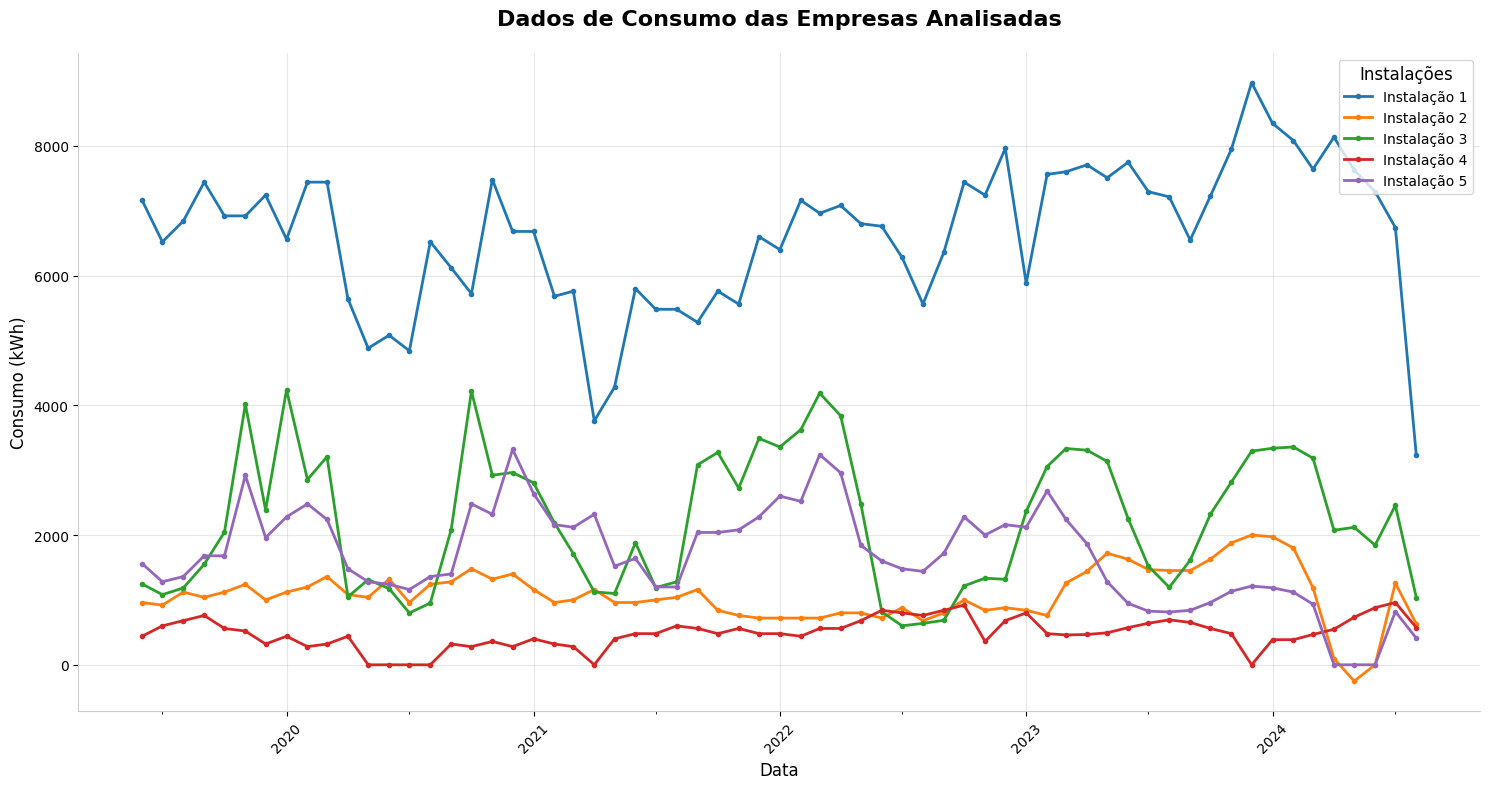

Gráfico salvo como: dados_consumo_originais.png


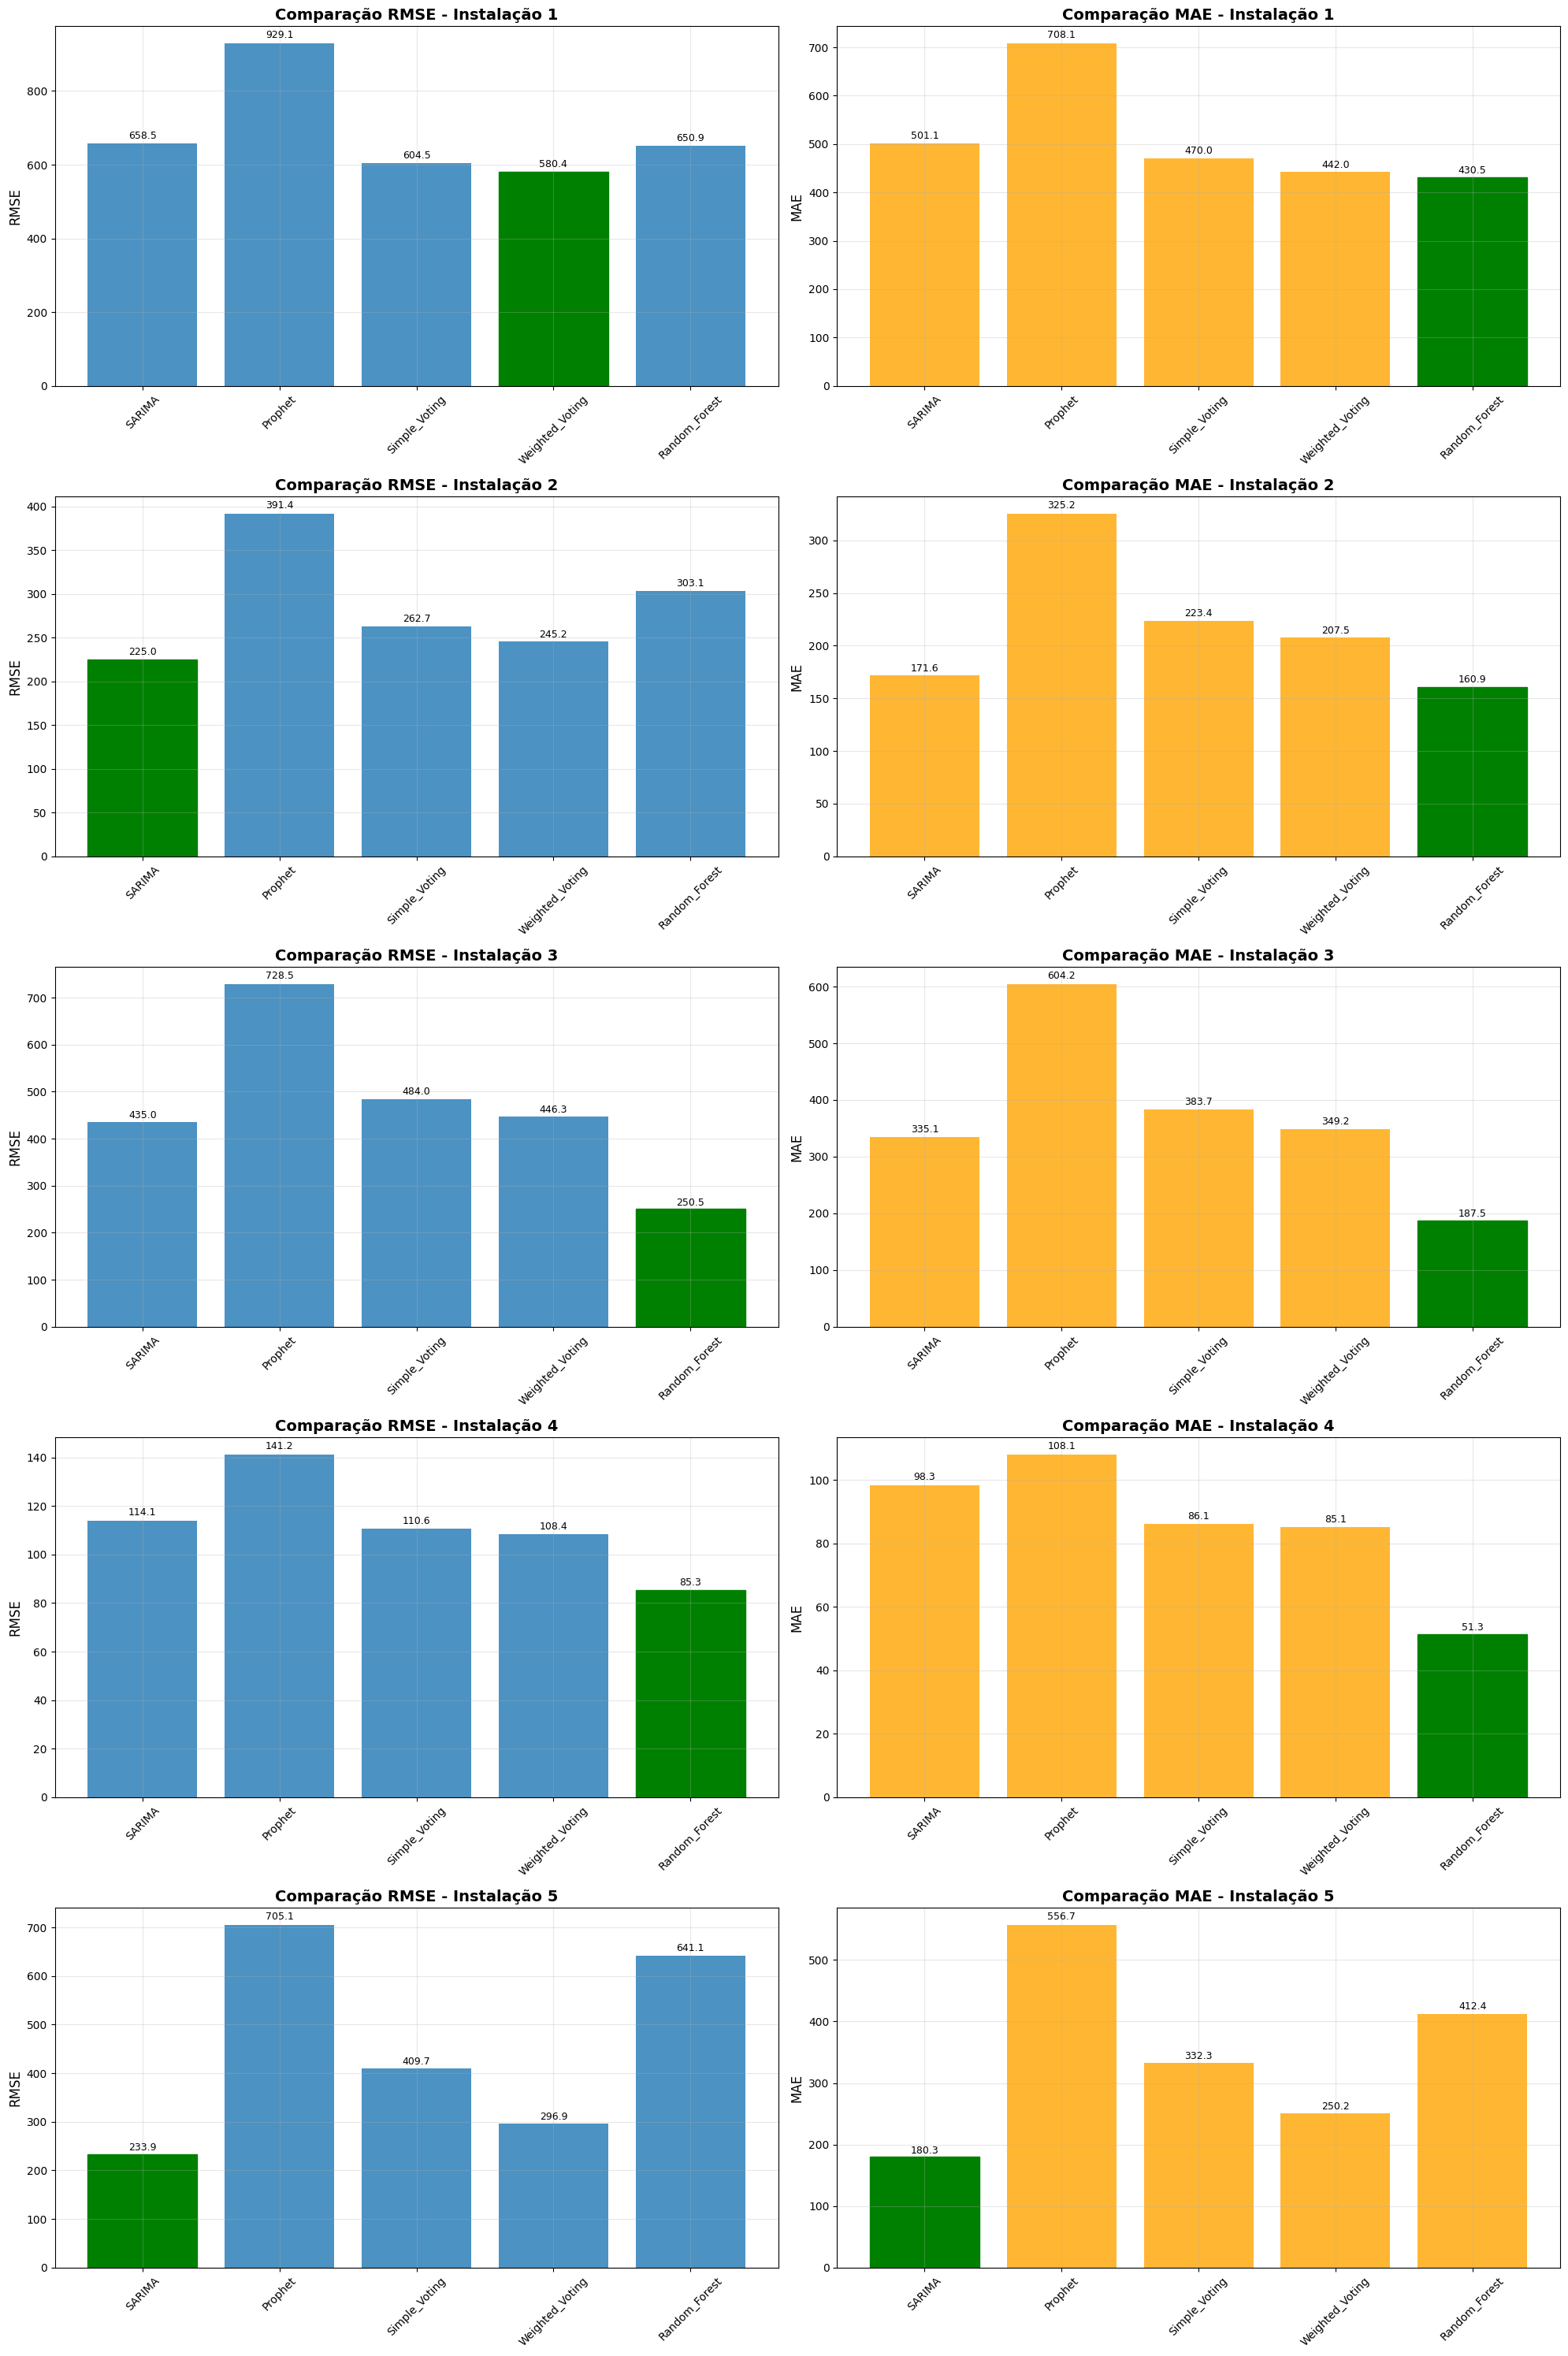

Gráfico salvo como: comparacao_todas_instalacoes_ensemble.png


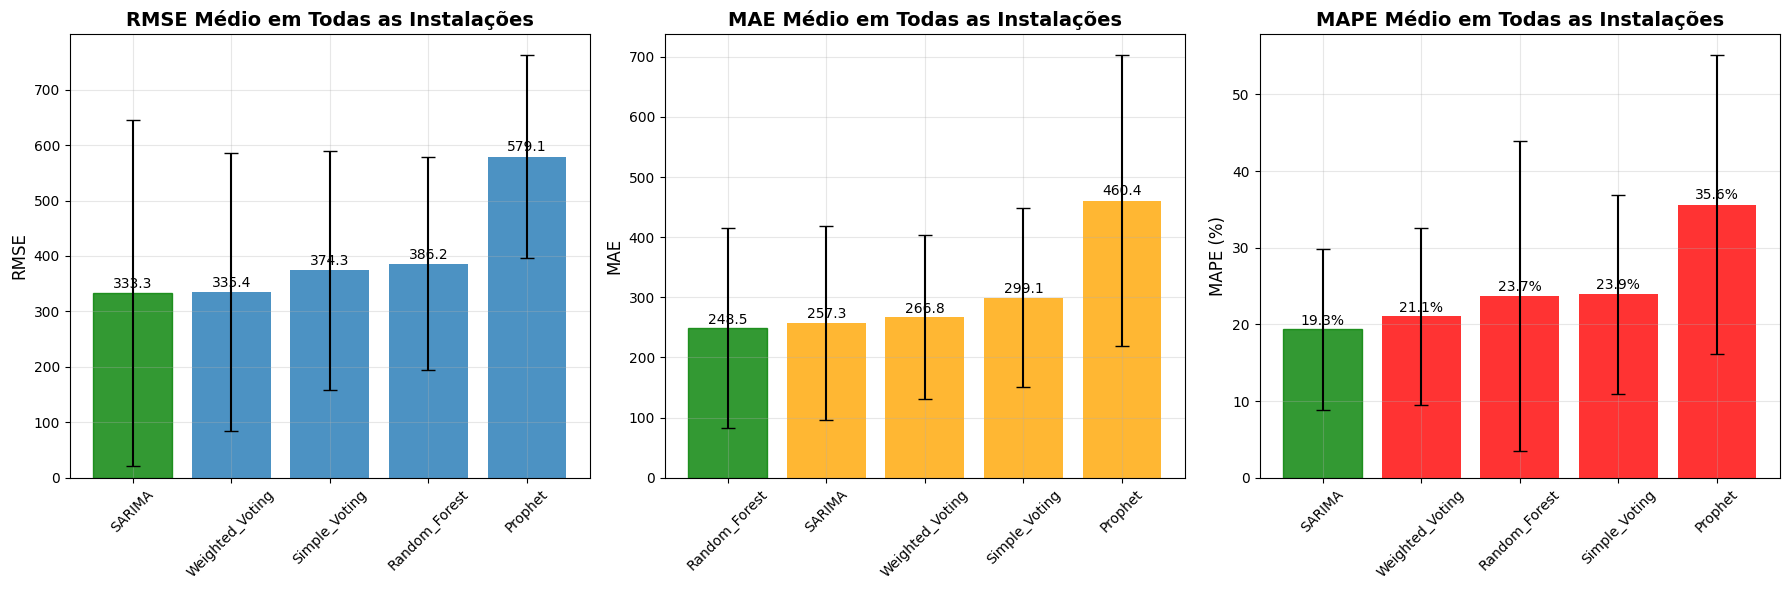

Gráfico salvo como: visao_geral_metodos_ensemble.png
Gerando comparação MAPE dos melhores modelos...


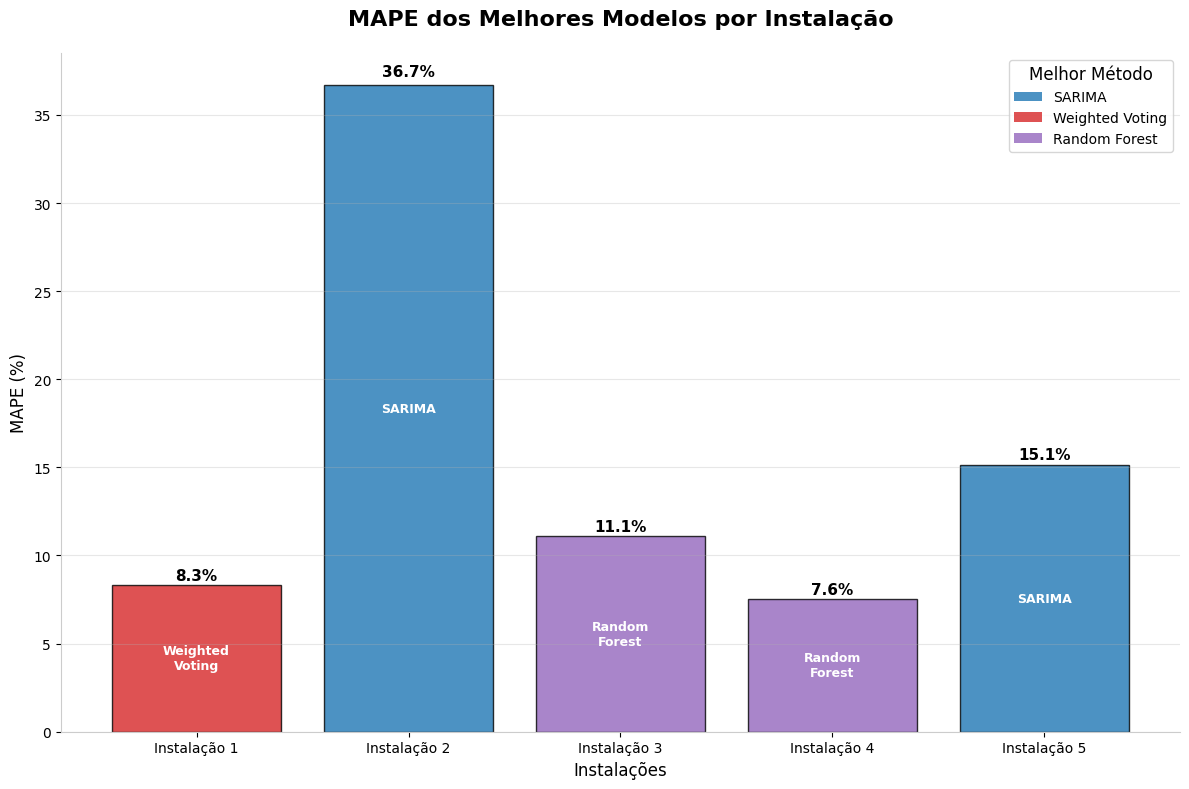

Gráfico salvo como: mape_melhores_modelos_por_instalacao.png

RESUMO DOS MELHORES MODELOS POR INSTALAÇÃO
Instalação      Melhor Método      MAPE (%)   RMSE      
------------------------------------------------------------
Instalação 1    Weighted_Voting         8.3    580.4
Instalação 2    SARIMA                 36.7    225.0
Instalação 3    Random_Forest          11.1    250.5
Instalação 4    Random_Forest           7.6     85.3
Instalação 5    SARIMA                 15.1    233.9
Gerando comparação de todas as métricas dos melhores modelos...


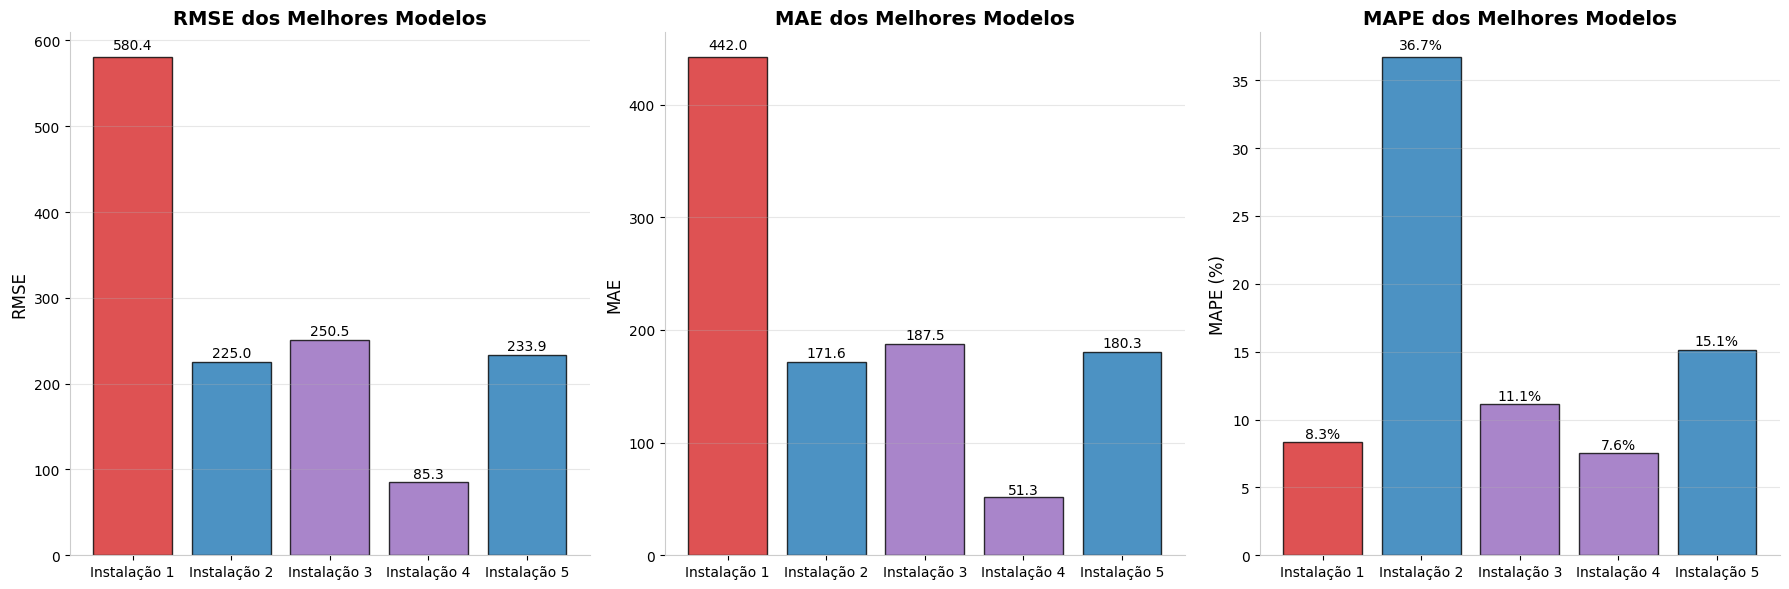

Gráfico salvo como: todas_metricas_melhores_modelos.png
Gerando gráfico individual para Instalação 1...


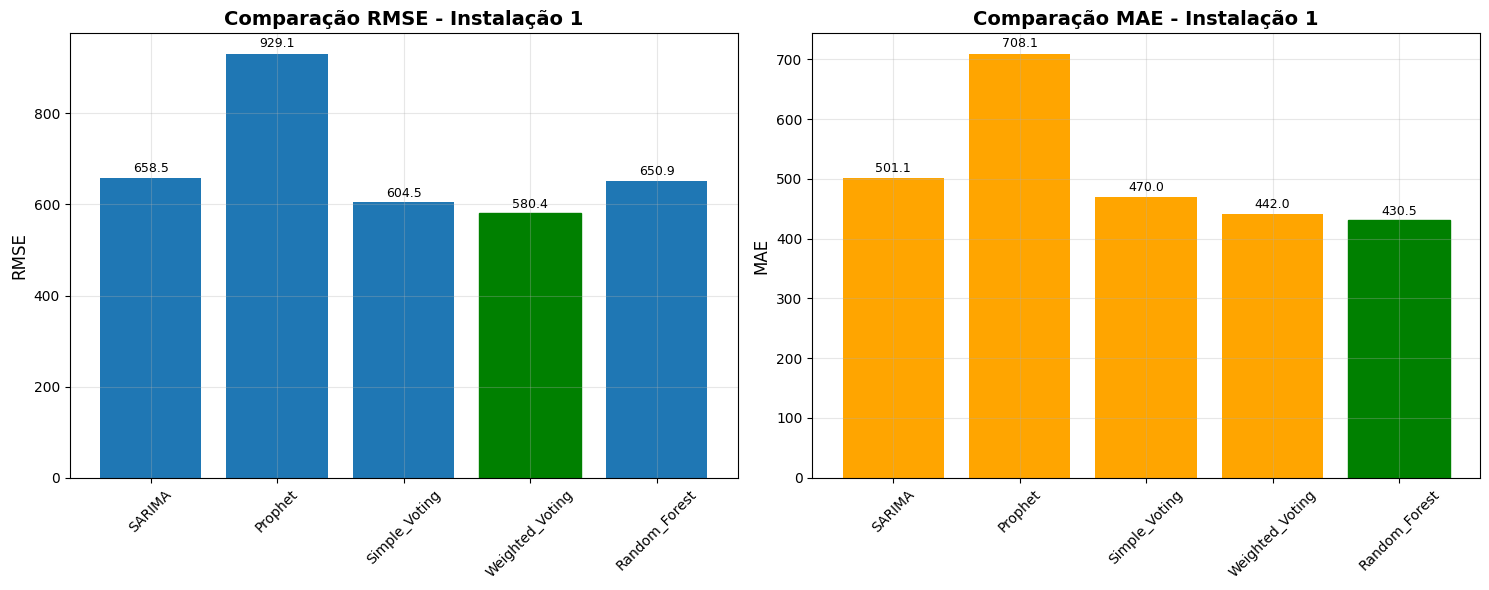

Gerando gráfico individual para Instalação 2...


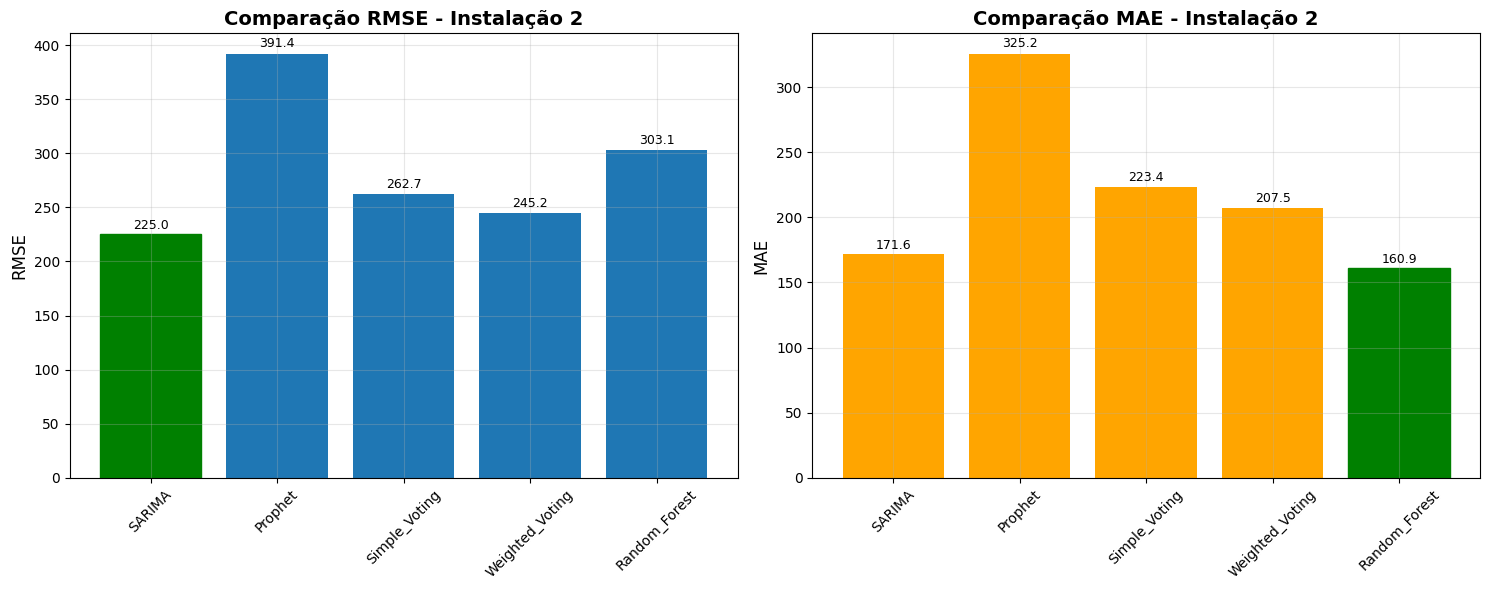

Gerando gráfico individual para Instalação 3...


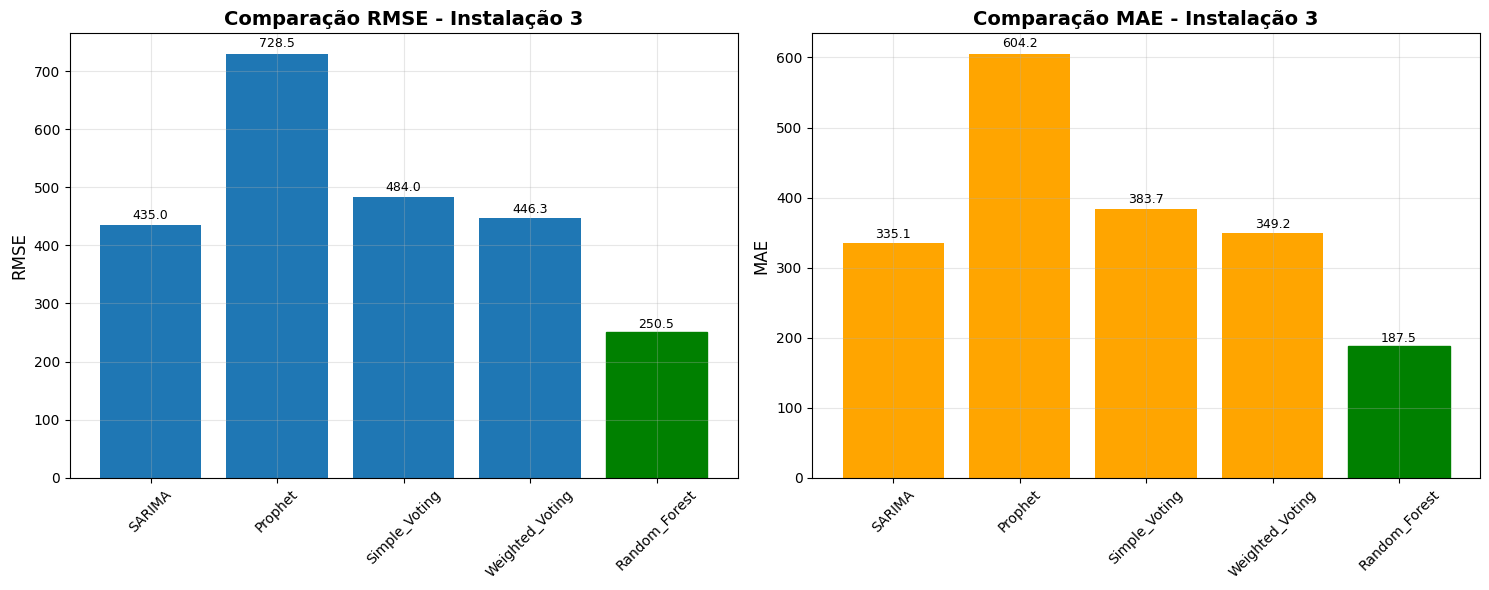

Gerando gráfico individual para Instalação 4...


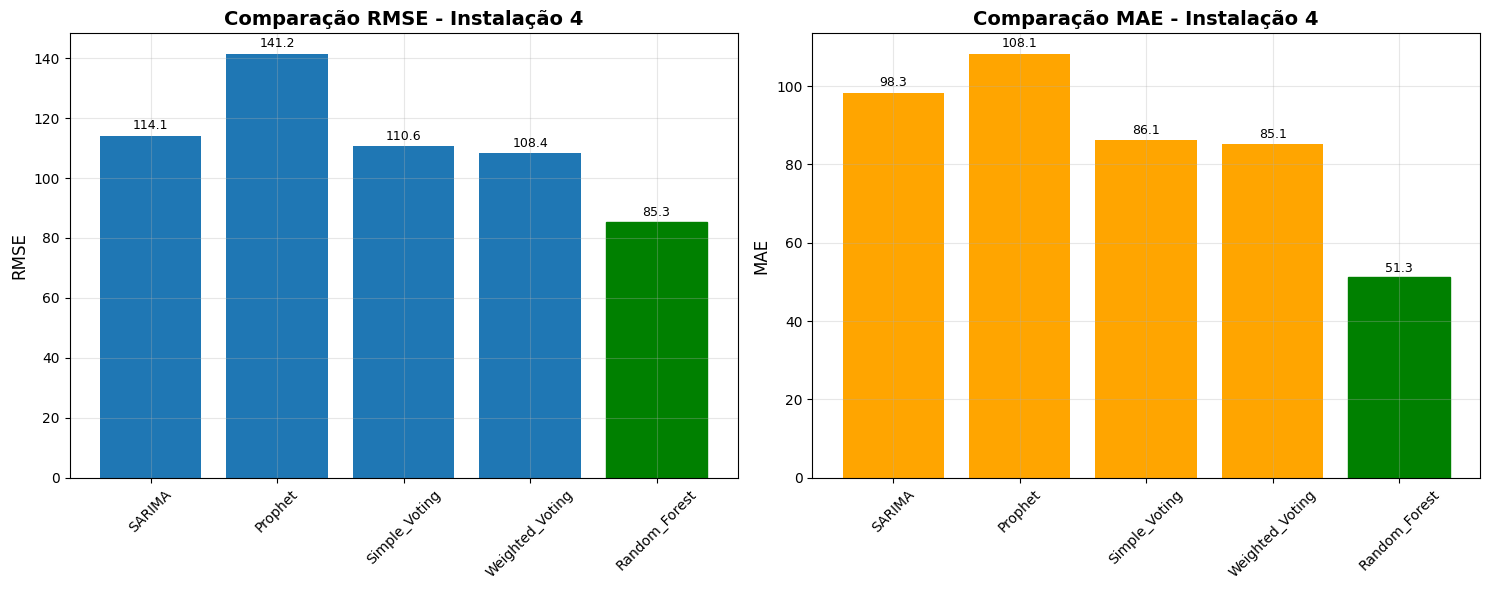

Gerando gráfico individual para Instalação 5...


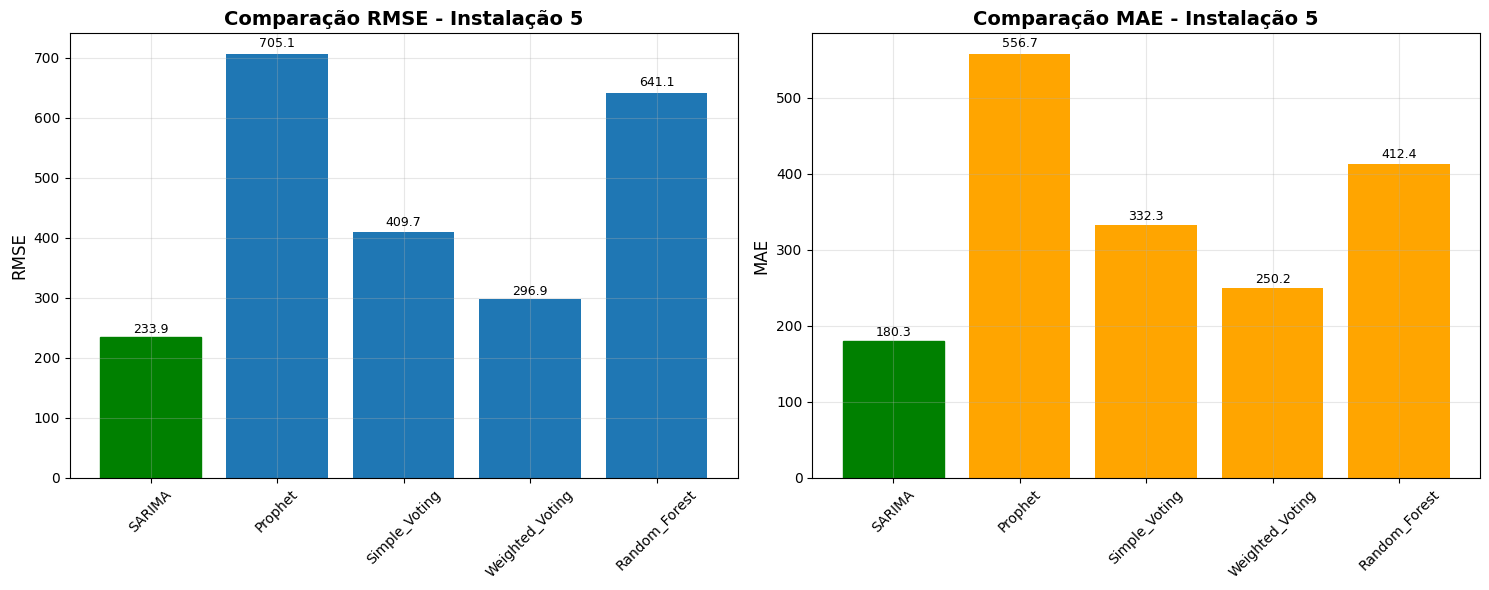


Todos os gráficos foram gerados com sucesso!
Arquivos criados:
- dados_consumo_originais.png
- comparacao_todas_instalacoes_ensemble.png
- visao_geral_metodos_ensemble.png
- mape_melhores_modelos_por_instalacao.png
- todas_metricas_melhores_modelos.png
- comparacao_ensemble_instalação_1.png
- comparacao_ensemble_instalação_2.png
- comparacao_ensemble_instalação_3.png
- comparacao_ensemble_instalação_4.png
- comparacao_ensemble_instalação_5.png


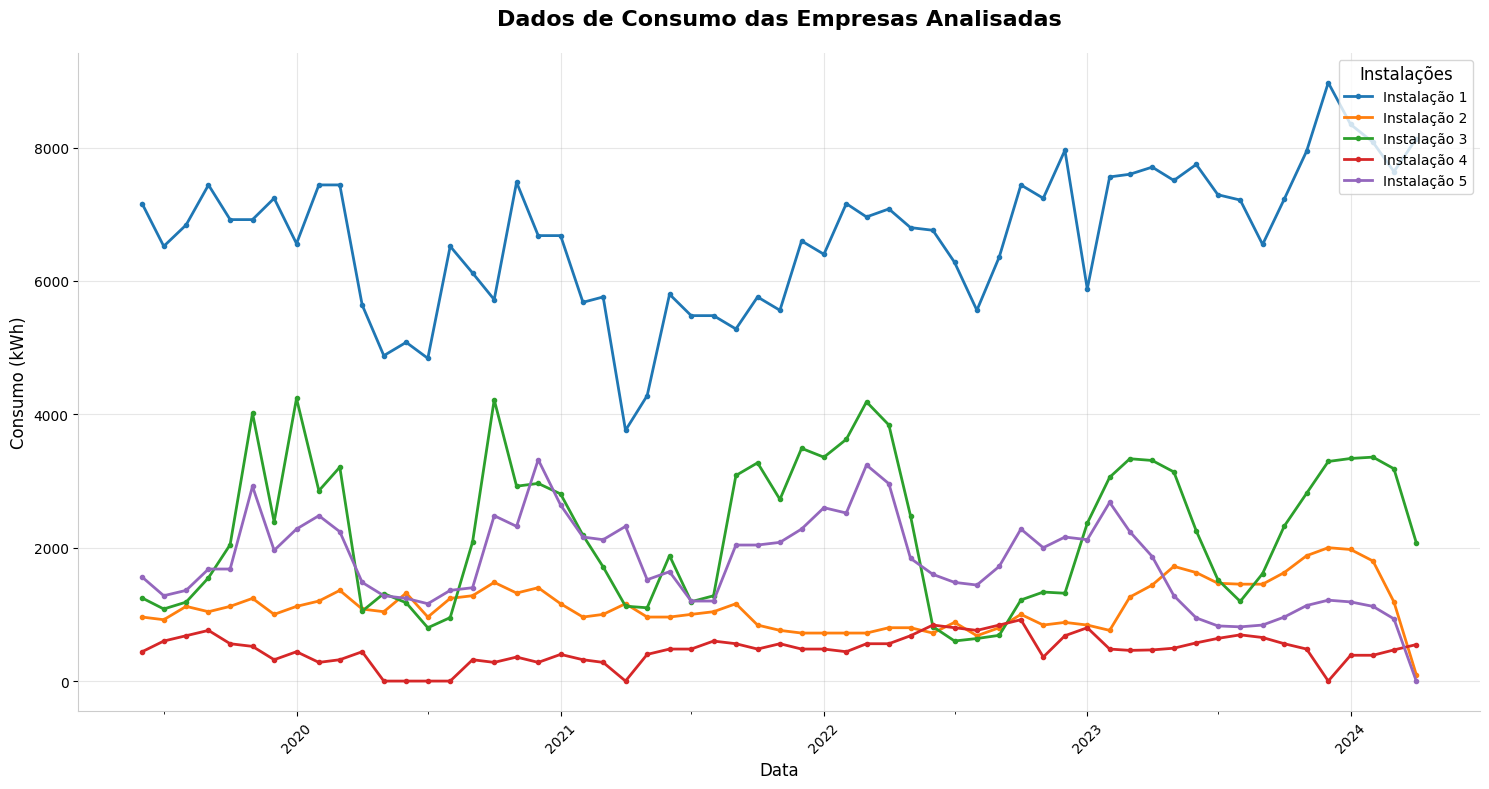

Gráfico salvo como: dados_consumo_originais.png


In [32]:
# ============================================================================
# RUN ANALYSIS
# ============================================================================

print("="*80)
print("ENSEMBLE METHODS FOR TIME SERIES FORECASTING")
print("Combining SARIMA and Prophet Models")
print("="*80)

# Run the analysis
results = run_ensemble_analysis()

if results is not None:
    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE!")
    print(f"{'='*80}")
    print("Files generated:")
    print("- ensemble_results.csv: Detailed results for all methods")
    print("\nNext steps:")
    print("1. Review ensemble_results.csv for detailed comparison")
    print("2. Use plot_ensemble_comparison() to visualize results")
    print("3. Choose the best ensemble method for each installation")

    generate_all_graphs(results, df_final)
    plot_original_data_consumption(df_final)
    
else:
    print("Analysis failed. Please check your data and parameter files.")